# Оценка риска развития рака у пациентов с полипами

## Цель раздела:

Определить вероятность перехода доброкачественного образования (полипа) в злокачественное (рак)

## План достижения цели:

1. Подготовка датасета
1. Feature Engineering
1. Моделирование
1. Оценка и сравнение полученных метрик

In [60]:
import os
from pathlib import Path
from dotenv import load_dotenv
import clickhouse_connect
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

## Подключение к аналитической базе данных 'oncology'

Доступ к переменным окружения:
- все конфиденциальные данные расположены в файле `/home/andrew/oncology_fhir_analytics/infrastructure/.env` и не сохранены в git-репозитории

In [2]:
# Определяем путь к .env файлу относительно текущего ноутбука
env_path = Path.cwd().parent / 'infrastructure' / '.env'
# Загружаем переменные из указанного пути
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print(f"Конфигурация загружена из: {env_path}")
else:
    print(f"Файл .env не найден по пути: {env_path}")

Конфигурация загружена из: /home/andrew/oncology_fhir_analytics/infrastructure/.env


Подключение к аналитической базе данных

In [3]:
# Подключаемся к ClickHouse
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username=os.getenv('CLICKHOUSE_USER', 'default'),
    password=os.getenv('CLICKHOUSE_PASSWORD', ''),
    database=os.getenv('CLICKHOUSE_DB', 'default')
)

def query_df(sql):
    return client.query_df(sql)

print("Подключение установлено.")

Подключение установлено.


## 1. Формирование витрины данных

### Основные принципы формирования витрины данных и расчетов признаков

1. **Определение точки отсчета** Дата самого раннего зафиксированного диагноза полипа. Все временные интервалы, возраст и стаж наблюдения рассчитываются относительно этого события.
2. **Соблюдение хронологической чистоты** Значения лабораторных маркеров (Hb, глюкоза) и клинических признаков фиксируются по принципу «последнего доступного значения» строго до или в момент индексной даты. Это гарантирует, что модель использует только те данные, которые были известны врачу в момент первичной находки, исключая «заглядывание в будущее».
3. **Трансформация событий в количественные признаки:** Множественные медицинские события из разных ресурсов (Procedure, Condition) агрегируются в числовые показатели интенсивности (количество выполненных полипэктомий, количество рецидивов). Это позволяет перевести историю болезни в плоский вектор признаков, пригодный для классических ML-алгоритмов.
5. **Валидация горизонта прогнозирования:** Формирование обучающей выборки включает обязательную фильтрацию по глубине анамнеза (не менее 5 лет наблюдения) и исключение случаев «одновременного обнаружения» (если рак выявлен в течение 30 дней после полипа). Это обеспечивает чистоту целевой переменной (Target) как истинного риска прогрессии.

### Описание структуры витрины данных

#### Социально-демографические признаки

| Признак | Источник (FHIR) | Описание | Тип данных |
| :--- | :--- | :--- | :--- |
| **gender** | `Patient.gender` | Учет гендерных различий | string |
| **race** | `Patient.extension` (US Core Race) | Оценка влияния этнических факторов | string |
| **age_at_index** | Вычисляемое: `Condition.onset` - `Patient.birthDate` | Определение возрастной группы риска | integer |

#### Клинические признаки

| Признак | Источник (FHIR) | Описание | Тип данных |
| :--- | :--- | :--- | :--- |
| **polyp_size** | `Observation` (LOINC 63488-1) | Размеры полипов | float |
| **recurrence_count** | `Condition` (count of SNOMED 68496003, 713197008) | Количество рецидивов полипов<br>recurrence_count = 0: Единичный случай полипа.<br>recurrence_count > 0: Рецидивирующий или множественный характер процесса (синхронные или метахронные образования), что статистически повышает риск накопления мутаций и малигнизации. | integer |
| **polypectomy_count** | `Procedure` ("Rectal polypectomy (procedure)") | Количество выполненных полипэктомий | integer |
| **treatment_gap** | Вычисляемое: (`Recurrence` + 1) - `Polypectomy` | Выявление "недолеченных" или оставленных полипов<br>treatment_gap = 0: Полная санация полипов.<br>treatment_gap > 0: Наличие оставленного (резидуального) субстрата | integer |

#### Лабораторные маркеры

| Признак | Источник (FHIR) | Описание | Тип данных |
| :--- | :--- | :--- | :--- |
| **hb_level** | `Observation` (LOINC 718-7) | Уровень гемоглобина на момент постановки диагноза "полип" | float |
| **glucose_level** | `Observation` (LOINC 2339-0) | Уровень глюкозы крови на момент постановки диагноза "полип" | float |
| **fobt_positive_flag** | `Observation` (LOINC 27396-1) | Исследование кала на скрытую кровь на момент постановки диагноза "полип" | binary |

#### Технические и целевые признаки
Используются для формирования обучающей выборки и валидации моделей.

| Признак | Источник | ДС-задача | Тип данных |
| :--- | :--- | :--- | :--- |
| **days_to_cancer** | Вычисляемое: `Cancer_date` - `Polyp_date` | Формирование целевой метки (Target) и фильтрация одновременных случаев | Числовой (Integer) |
| **is_deceased** | `Patient.deceased` | Анализ конкурирующих рисков и учет выбывания из-под наблюдения (цензурирование) | Бинарный (0/1) |
| **observation_years** | Вычисляемое: `Today` - `Polyp_date` | Валидация качества выборки по глубине анамнеза (требуется горизонт >= 5 лет) | Числовой (Integer) |

### Загрузка витрины данных

In [55]:
# создание витрины данных
df_assessing_cancer_risk = query_df("""
SELECT 
    fp.patient_id,
    p.gender,
    p.race,
    dateDiff('year', p.birth_date, toDate(fp.index_date)) AS age_at_index,
    coalesce(recur.cnt, 0) AS recurrence_count,
    morph.sz AS polyp_size,
    hb.val AS hb_level,
    gluc.val AS glucose_level,
    coalesce(proc.cnt, 0) AS polypectomy_count,
    -- Расчет: сколько полипов осталось не удалено
    (toInt32(coalesce(recur.cnt, 0)) + 1) - toInt32(coalesce(proc.cnt, 0)) AS treatment_gap,
    multiIf(fobt.raw IN ('Positive', 'Present'), 1, fobt.raw IN ('Negative', 'Absent'), 0, NULL) AS fobt_positive_flag,
    dateDiff('day', toDate(fp.index_date), toDate(fc.cancer_date)) AS days_to_cancer,
    p.is_deceased,
    dateDiff('year', toDate(fp.index_date), today()) AS observation_years
FROM (
    -- Базовая когорта: пациенты с первым полипом
    SELECT patient_id, min(onset_at) AS index_date
    FROM oncology.conditions 
    WHERE code IN ('68496003', '713197008')
    GROUP BY patient_id
) AS fp
INNER JOIN oncology.patients AS p ON fp.patient_id = p.patient_id
LEFT JOIN (
    -- Дата первого рака
    SELECT patient_id, min(onset_at) AS cancer_date
    FROM oncology.conditions 
    WHERE code IN ('109838007', '363406005', '93761005')
    GROUP BY patient_id
) AS fc ON fp.patient_id = fc.patient_id
LEFT JOIN (
    -- Рецидивы (диагнозы после первого полипа)
    SELECT c.patient_id AS pid, count() AS cnt
    FROM oncology.conditions AS c
    INNER JOIN (
        SELECT patient_id, min(onset_at) AS idt 
        FROM oncology.conditions 
        WHERE code IN ('68496003', '713197008') 
        GROUP BY patient_id
    ) AS b ON c.patient_id = b.patient_id
    WHERE c.code IN ('68496003', '713197008') AND c.onset_at > b.idt
    GROUP BY pid
) AS recur ON fp.patient_id = recur.pid
LEFT JOIN (
    -- Полипэктомии
    SELECT patient_id AS pid, count() AS cnt
    FROM oncology.procedures
    WHERE display = 'Rectal polypectomy (procedure)'
    GROUP BY pid
) AS proc ON fp.patient_id = proc.pid
LEFT JOIN (
    -- Размер полипа
    SELECT patient_id AS pid, argMax(value_number, effective_at) AS sz
    FROM oncology.observations WHERE display LIKE '%Polyp size%' GROUP BY pid
) AS morph ON fp.patient_id = morph.pid
LEFT JOIN (
    -- Лабораторные данные
    SELECT patient_id AS pid, argMax(value_number, effective_at) AS val
    FROM oncology.observations WHERE display LIKE 'Hemoglobin%' GROUP BY pid
) AS hb ON fp.patient_id = hb.pid
LEFT JOIN (
    SELECT patient_id AS pid, argMax(value_number, effective_at) AS val
    FROM oncology.observations WHERE display LIKE 'Glucose%' GROUP BY pid
) AS gluc ON fp.patient_id = gluc.pid
LEFT JOIN (
    SELECT patient_id AS pid, count() AS cnt
    FROM oncology.encounters GROUP BY pid
) AS enc ON fp.patient_id = enc.pid
LEFT JOIN (
    -- Скрытая кровь
    SELECT patient_id AS pid, argMax(value_string, effective_at) AS raw
    FROM oncology.observations WHERE display LIKE 'Hemoglobin.gastrointestinal.lower%' GROUP BY pid
) AS fobt ON fp.patient_id = fobt.pid
""")

df_assessing_cancer_risk.shape

(6452, 14)

In [56]:
df_assessing_cancer_risk.head()

,fp.patient_id,gender,race,age_at_index,recurrence_count,polyp_size,hb_level,glucose_level,polypectomy_count,treatment_gap,fobt_positive_flag,days_to_cancer,is_deceased,observation_years
0,766c3960-68c7-6da4-0267-96fca4e155c3,male,Black or African American,75,1,6.0711,13.126,88.01,2,0,<NA>,538,1,15
1,94470135-20fe-3fcd-d6e4-5085ceda1750,female,Black or African American,61,1,5.8417,6.570,93.52,2,0,<NA>,383,1,25
2,79155e97-0493-cd03-91d1-f5d212cc3f93,female,White,50,1,4.9742,13.024,97.20,2,0,<NA>,539,0,3
3,10027f14-b0d7-c853-9888-22eb9b8d6659,male,White,70,1,4.5193,11.705,NaN,2,0,<NA>,441,1,15
4,0f59df93-97ac-cf33-1bb9-14ce2e754d57,male,White,65,1,2.9622,7.215,72.69,2,0,<NA>,527,0,15


### Удаление лишних наблюдений

Нам нужно убрать из выборки два типа пациентов:
1. **Одновременные находки**: Пациенты, у кого рак был обнаружен сразу после полипа (в течение 30 дней). Это не прогрессия полипа, а просто выявленная за одну процедуру опухоль.
1. **Неопределенные случаи**: Пациенты, у кого рака нет (в наших данных), но мы наблюдали за ними меньше 5 лет. Мы не можем на 100% утверждать, что они «здоровы», так как рак мог развиться на 4-й или 5-й год, которые не попали в выгрузку.

In [57]:
# Исключаем одновременные находки (<= 30 дней)
df_assessing_cancer_risk_clean = df_assessing_cancer_risk[
    (df_assessing_cancer_risk['days_to_cancer'].isna()) | 
    (df_assessing_cancer_risk['days_to_cancer'] > 30)
].copy()

# Исключаем пациентов, которые не попали в 5-летний горизонт наблюдения
df_assessing_cancer_risk_clean = df_assessing_cancer_risk_clean[
    (df_assessing_cancer_risk_clean['days_to_cancer'].notna()) | 
    (df_assessing_cancer_risk_clean['observation_years'] >= 5)
].copy()

print(f"Из {df_assessing_cancer_risk.shape[0]} пациентов после фильтрации осталось : {df_assessing_cancer_risk_clean.shape[0]}")

Из 6452 пациентов после фильтрации осталось : 4118


### Создание целевой переменной

Мы обучаем модель предсказывать риск малигнизации в течение 5 лет (1825 дней).

In [58]:
# Target = 1, если рак развился в интервале от 31 до 1825 дней включительно.
df_assessing_cancer_risk_clean['target'] = (
    (df_assessing_cancer_risk_clean['days_to_cancer'] > 30) & 
    (df_assessing_cancer_risk_clean['days_to_cancer'] <= 1825)
).astype(int)

# Посмотрим на баланс классов
print("Баланс классов:")
print(df_assessing_cancer_risk_clean['target'].value_counts(normalize=True))

Баланс классов:
target
1    0.717824
0    0.282176
Name: proportion, dtype: float64


### Анализ пропусков

In [59]:
# Смотрим количество пропусков в каждом столбце
missing_data = df_assessing_cancer_risk_clean.isnull().sum()
missing_percent = (df_assessing_cancer_risk_clean.isnull().sum() / len(df_assessing_cancer_risk_clean) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Values': missing_data.values,
    'Percentage (%)': missing_percent.values
})

print(missing_df.sort_values(by='Percentage (%)', ascending=False))

                Column  Missing Values  Percentage (%)
10  fobt_positive_flag            4118          100.00
7        glucose_level            1626           39.49
0        fp.patient_id               0            0.00
3         age_at_index               0            0.00
4     recurrence_count               0            0.00
1               gender               0            0.00
2                 race               0            0.00
6             hb_level               0            0.00
5           polyp_size               0            0.00
8    polypectomy_count               0            0.00
9        treatment_gap               0            0.00
11      days_to_cancer               0            0.00
12         is_deceased               0            0.00
13   observation_years               0            0.00
14              target               0            0.00


**Результаты анализа пропусков**:
1. Признак `fobt_positive_flag` содержит 100% пропусков: Это «мертвый» признак. Скорее всего пациентам с впервые выявленными полипами не проводилось исследование кала на скрытую кровь. По этой причине мы удаляем удаляем `fobt_positive_flag` из списка предикторов для обучения модели.
1. Признак `glucose_level` - 39.5% пропусков. Это серьезно, но не критично. Для CatBoost это вообще не проблема — он умеет обрабатывать пропуски как отдельную категорию. Для Logistic Regression нам придется заполнить их средним значением (Медианой). Но перед этим мы проверим, имеются ли статистически значимые различия между групами по этому признаку. Если нет - то `glucose_level` будет цедесообразно исключить из спимка предикторов тоже.
1. Остальные признаки не содержат пропусков.

#### Статистическое исследование уровня глюкозы

**План анализа**:
1. Выделим только те строки, где глюкоза заполнена.
1. Проверка на нормальность: Определим, какой тест использовать (параметрический T-test или непараметрический Mann-Whitney).
1. Тестирование: Сравним группы Target=0 и Target=1.
1. Визуализация: Построим Boxplot (ящык с усами).

In [61]:
# Убираем пропуски только для этого анализа
gluc_analysis = df_assessing_cancer_risk_clean[['glucose_level', 'target']].dropna()

group_0 = gluc_analysis[gluc_analysis['target'] == 0]['glucose_level']
group_1 = gluc_analysis[gluc_analysis['target'] == 1]['glucose_level']

In [62]:
# Проверка на нормальность (тест Шапиро-Уилка)
# Если p > 0.05, распределение нормальное
_, p_norm_0 = stats.shapiro(group_0.sample(min(len(group_0), 500))) 
_, p_norm_1 = stats.shapiro(group_1.sample(min(len(group_1), 500)))

print(f"P-value нормальности (группа 0): {p_norm_0:.4f}")
print(f"P-value нормальности (группа 1): {p_norm_1:.4f}")

P-value нормальности (группа 0): 0.0000
P-value нормальности (группа 1): 0.0000


In [ ]:
# Выбор и проведение теста
if p_norm_0 > 0.05 and p_norm_1 > 0.05:
    # Параметрический тест Стьюдента
    t_stat, p_val = stats.ttest_ind(group_0, group_1)
    test_name = "T-test (параметрический)"
else:
    # Непараметрический тест Манна-Уитни
    u_stat, p_val = stats.mannwhitneyu(group_0, group_1)
    test_name = "Mann-Whitney U test (непараметрический)"

print(f"\nИспользован метод: {test_name}")
print(f"P-value значимости различий: {p_val:.4f}")


Использован метод: Mann-Whitney U test (непараметрический)
P-value значимости различий: 0.6458


/tmp/ipykernel_49930/2434421690.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=group_labels, patch_artist=True,


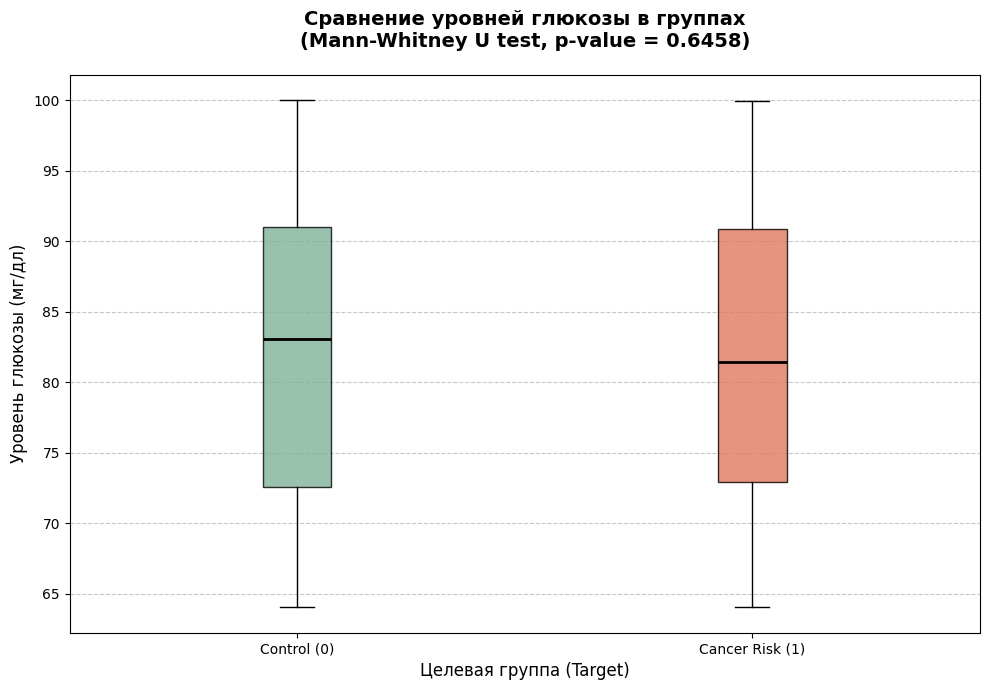


Описательные статистики:
         count       mean        std    min     25%    50%    75%     max
target                                                                   
0        497.0  82.193984  10.411175  64.02  72.580  83.04  90.97  100.00
1       1995.0  81.944942  10.348401  64.02  72.945  81.41  90.85   99.97


In [ ]:
# Группы и цвета (зеленый для контроля, красноватый для группы риска)
group_labels = ['Control (0)', 'Cancer Risk (1)']
colors = ['#81b29a', '#e07a5f']

ig, ax = plt.subplots(figsize=(10, 7))

bp = ax.boxplot(data_to_plot, labels=group_labels, patch_artist=True, 
                medianprops={'color': 'black', 'linewidth': 2},
                showfliers=True) # Показываем выбросы, так как в глюкозе они важны

# Применяем стиль
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title(f'Сравнение уровней глюкозы в группах\n(Mann-Whitney U test, p-value = {p_val:.4f})', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Целевая группа (Target)', fontsize=12)
ax.set_ylabel('Уровень глюкозы (мг/дл)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Описательные статистики
print("\nОписательные статистики:")
print(gluc_analysis.groupby('target')['glucose_level'].describe())

**Результаты статистического исследования уровня глюкозы крови**

1. Распределение значиний уровня глюкозы в группах не является нормальным.
1. При использовании непараметрических статистических методов нами не было выявлено статистических значимых различий по значениям уровня глюкозы между группами.

**Вывод:** Признак `glucose_level` также надо будет удалить из числа предикторов, используемых в обучении моделей.


### Удаление признаков из финального датасета

In [75]:
# Оставляем только те признаки, которые прошли проверку на качество
df_assessing_cancer_risk_final = df_assessing_cancer_risk_clean.drop(columns=['glucose_level', 'fobt_positive_flag'])
df_assessing_cancer_risk_final.head()

,fp.patient_id,gender,race,age_at_index,recurrence_count,polyp_size,hb_level,polypectomy_count,treatment_gap,days_to_cancer,is_deceased,observation_years,target
0,766c3960-68c7-6da4-0267-96fca4e155c3,male,Black or African American,75,1,6.0711,13.126,2,0,538,1,15,1
1,94470135-20fe-3fcd-d6e4-5085ceda1750,female,Black or African American,61,1,5.8417,6.570,2,0,383,1,25,1
2,79155e97-0493-cd03-91d1-f5d212cc3f93,female,White,50,1,4.9742,13.024,2,0,539,0,3,1
3,10027f14-b0d7-c853-9888-22eb9b8d6659,male,White,70,1,4.5193,11.705,2,0,441,1,15,1
4,0f59df93-97ac-cf33-1bb9-14ce2e754d57,male,White,65,1,2.9622,7.215,2,0,527,0,15,1


### Анализ выбросов

Для числовых данных мы будем использовать статистический метод IQR (межквартильный размах) и клинический здравый смысл.

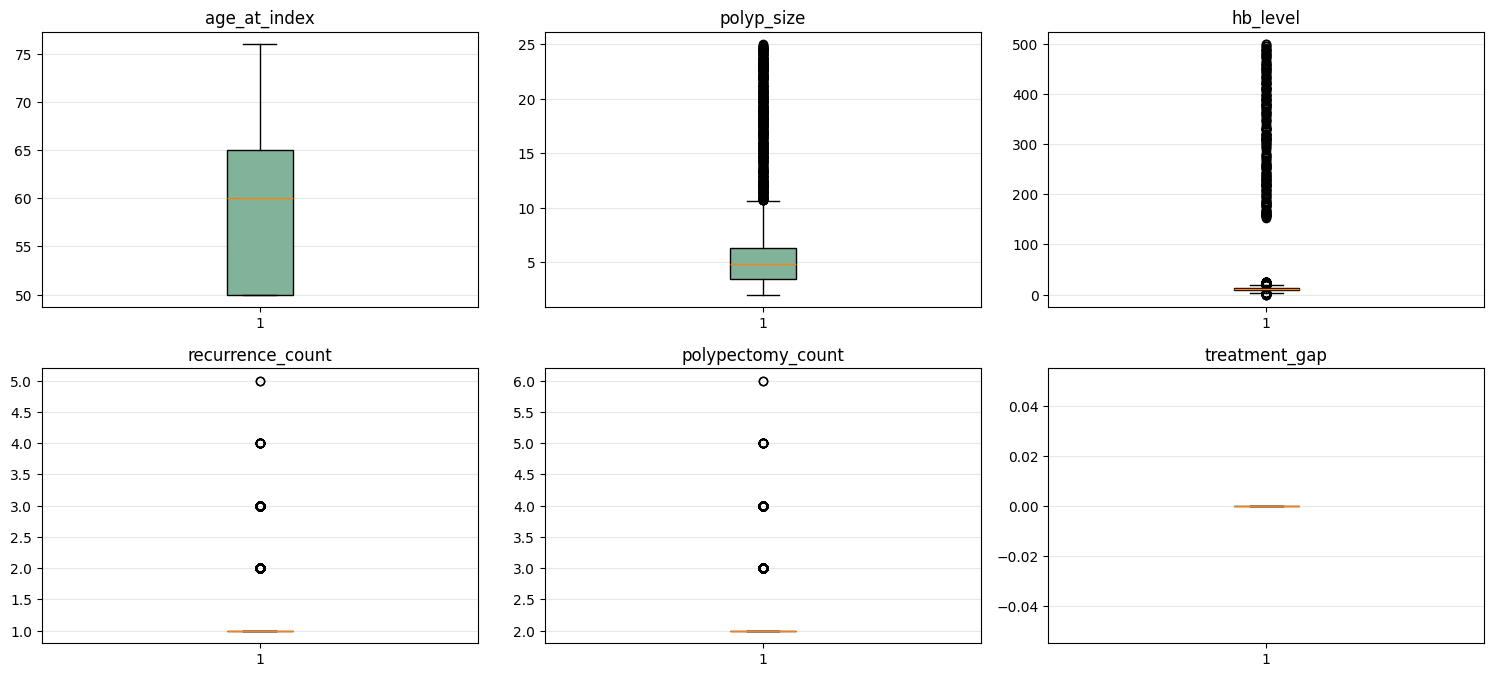

       age_at_index   polyp_size     hb_level  recurrence_count  \
count        4118.0  4118.000000  4118.000000       4118.000000   
mean      59.114862     6.090161    31.763027          1.236523   
std        7.762861     4.730368    82.026957          0.527050   
min            50.0     2.007000     0.008438          1.000000   
1%             50.0     2.079876     2.359807          1.000000   
25%            50.0     3.406750     9.103350          1.000000   
50%            60.0     4.813100    11.212000          1.000000   
75%            65.0     6.277450    13.102500          1.000000   
99%            75.0    23.673620   446.614500          3.000000   
max            76.0    24.994000   498.790000          5.000000   

       polypectomy_count  treatment_gap  
count        4118.000000         4118.0  
mean            2.236523            0.0  
std             0.527050            0.0  
min             2.000000            0.0  
1%              2.000000            0.0  
25%       

In [78]:
num_cols = ['age_at_index', 'polyp_size', 'hb_level', 'recurrence_count', 
            'polypectomy_count', 'treatment_gap']

# Построим боксплоты для всех числовых признаков, чтобы увидеть выбросы
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(df_assessing_cancer_risk_final[col], patch_artist=True, boxprops=dict(facecolor='#81b29a'))
    plt.title(col)
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Описательная статистика для поиска экстремальных значений
print(df_assessing_cancer_risk_final[num_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]))

### Обучение моделей

#### Подготовка матрицы признаков

In [ ]:
# Определяем целевую переменную
y = df_final['target']

# Определяем матрицу признаков (убираем таргет и лишние столбцы)
X = df_final.drop(columns=[
    'target', 
    'fp.patient_id', 
    'days_to_cancer', 
    'observation_years', 
    'is_deceased',
    'fobt_positive_flag' # Удаляем, так как он пустой на 100%
])

# Проверим, что осталось
print("Итоговые признаки для обучения:")
print(X.columns.tolist())

#### Разделение на обучающую и тестовую выборки